In [1]:
# =====================================================
# TASK 1 : DATA LOADING, MERGING & DEEP EXPLORATION
# =====================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_csv("train.csv", encoding="latin1")

# Display Dataset
print("="*60)
print("FIRST 10 ROWS")
print("="*60)
print(df.head(10))

print("\n" + "="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns)

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
df.info()

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe(include="all"))

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("DUPLICATE RECORDS")
print("="*60)
print(df.duplicated().sum())

# Convert Date Columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Extract Time Features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Month Number"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

# Season Feature
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month Number"].apply(get_season)

# Shipping Days
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

# Weekly Sales
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()

# Monthly Sales
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()

print("\n" + "="*60)
print("WEEKLY SALES")
print("="*60)
print(weekly_sales.head())

print("\n" + "="*60)
print("MONTHLY SALES")
print("="*60)
print(monthly_sales.head())

FIRST 10 ROWS
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
5       6  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
6       7  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
7       8  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
8       9  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   
9      10  CA-2015-115812  09/06/2015  14/06/2015  Standard Class    BH-11710   

     Customer Name    Segment        Country             City       State  \
0      Claire Gut

Monthly Sales
Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


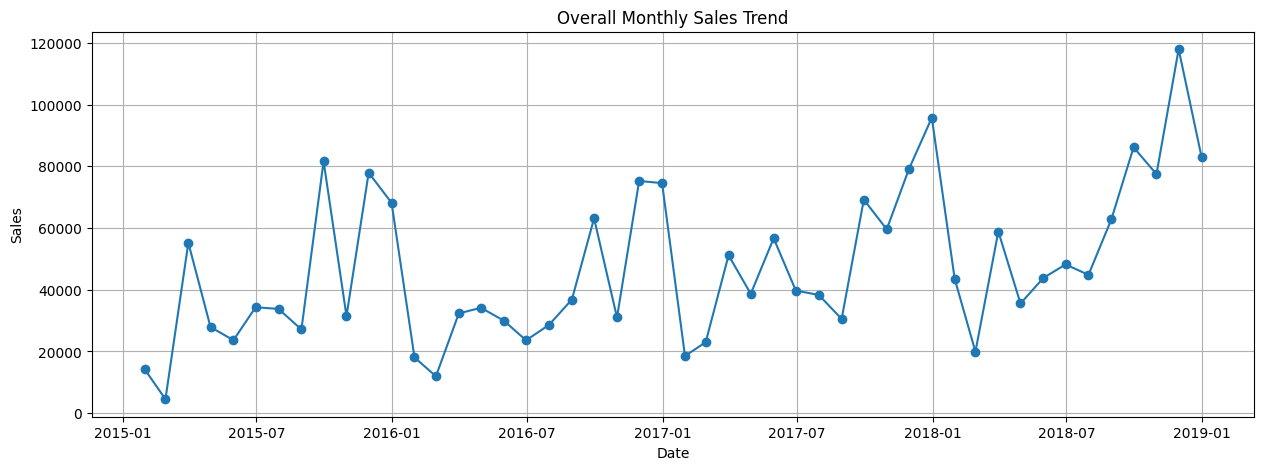

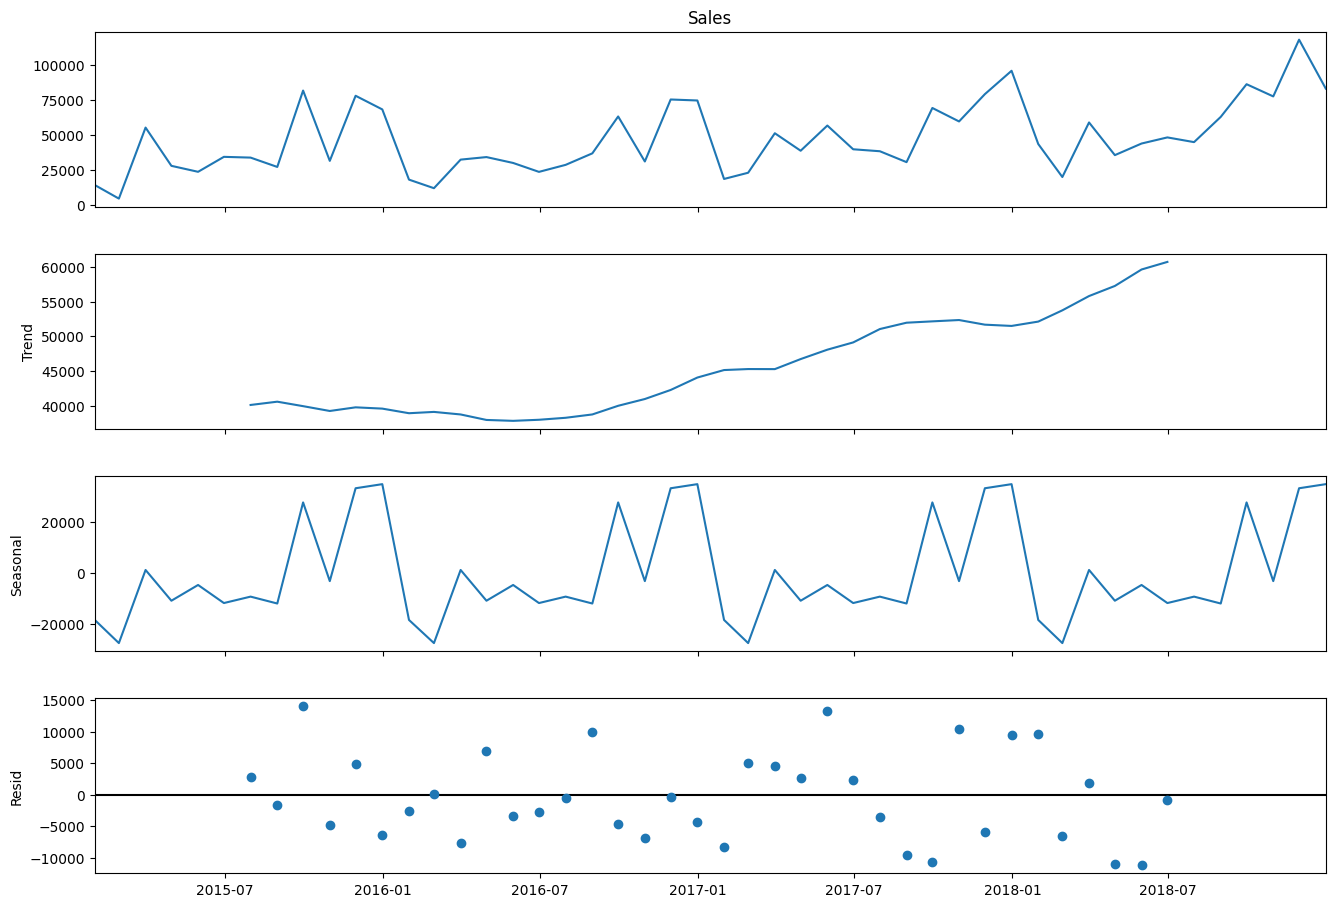

ADF TEST RESULT
ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623
Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064

Result:
The time series is stationary.


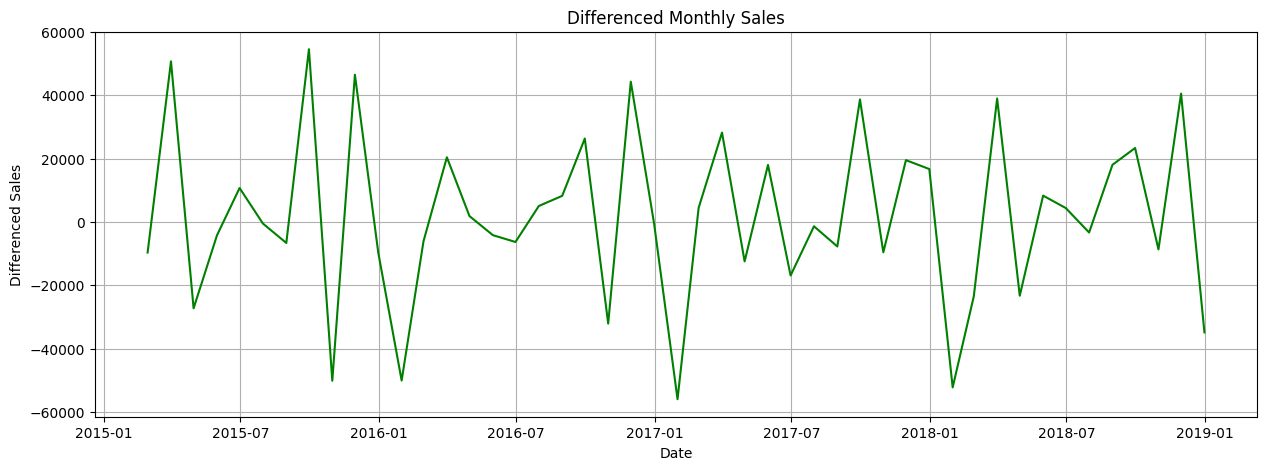

ADF TEST AFTER DIFFERENCING
ADF Statistic : -8.727061830353268
p-value       : 3.2669175472796045e-14
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383

After differencing, the series is stationary.


In [ ]:
# =====================================================
# TASK 2 : TIME SERIES ANALYSIS & DECOMPOSITION
# =====================================================

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Monthly Sales
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

print("Monthly Sales")
print(monthly_sales.head())

# -----------------------------------------------------
# Plot Overall Monthly Sales Trend
# -----------------------------------------------------

plt.figure(figsize=(15,5))
plt.plot(monthly_sales, marker='o')
plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# -----------------------------------------------------
# Time Series Decomposition
# -----------------------------------------------------

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

# -----------------------------------------------------
# ADF Test
# -----------------------------------------------------

print("="*60)
print("ADF TEST RESULT")
print("="*60)

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key} : {value}")

# -----------------------------------------------------
# Stationarity Check
# -----------------------------------------------------

if result[1] < 0.05:
    print("\nResult:")
    print("The time series is stationary.")
else:
    print("\nResult:")
    print("The time series is NOT stationary.")

# -----------------------------------------------------
# Apply Differencing
# -----------------------------------------------------

monthly_sales_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(15,5))
plt.plot(monthly_sales_diff, color='green')
plt.title("Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.show()

# -----------------------------------------------------
# ADF Test After Differencing
# -----------------------------------------------------

print("="*60)
print("ADF TEST AFTER DIFFERENCING")
print("="*60)

result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", result_diff[0])
print("p-value       :", result_diff[1])

for key, value in result_diff[4].items():
    print(f"{key} : {value}")

if result_diff[1] < 0.05:
    print("\nAfter differencing, the series is stationary.")
else:
    print("\nAfter differencing, the series is still not stationary.")

In [ ]:
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

MODEL 1 : SARIMA


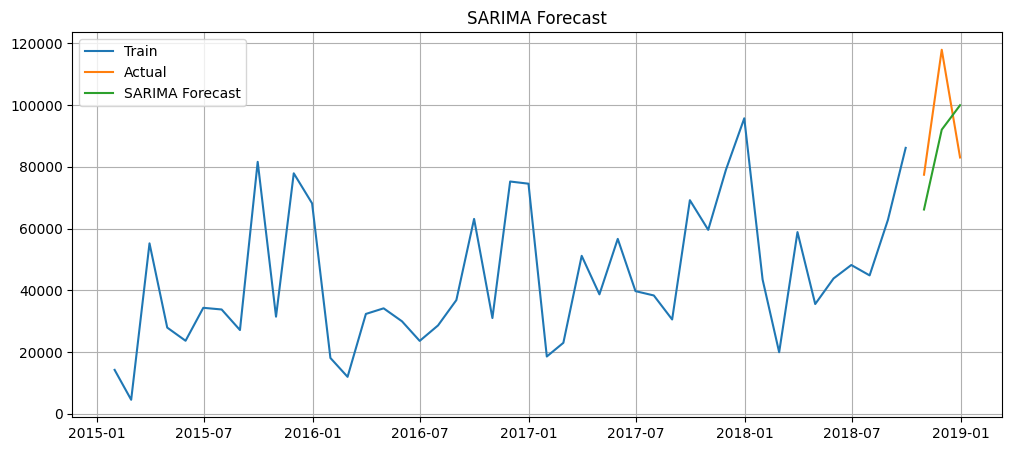

MODEL 2 : PROPHET


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


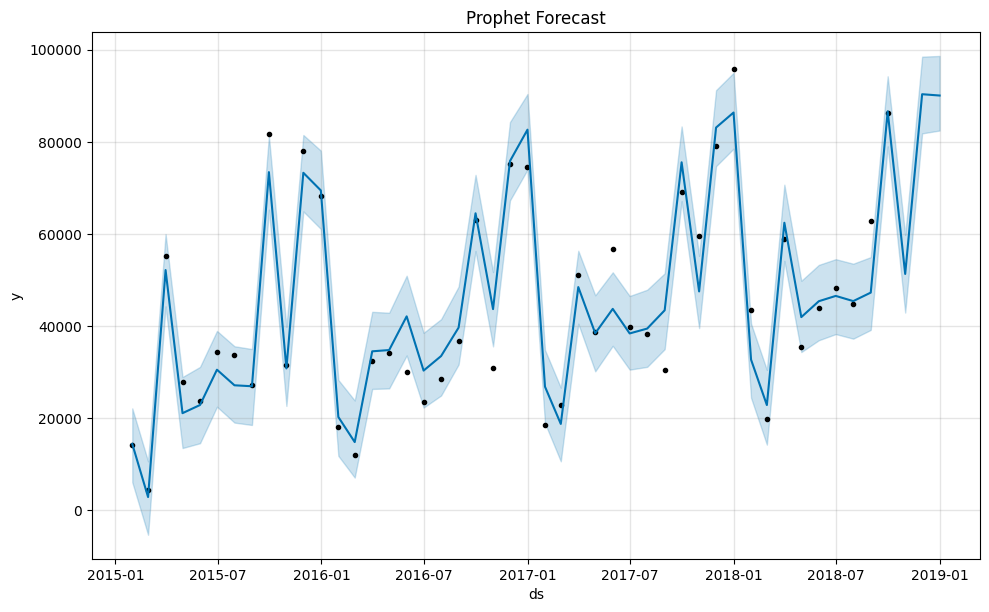

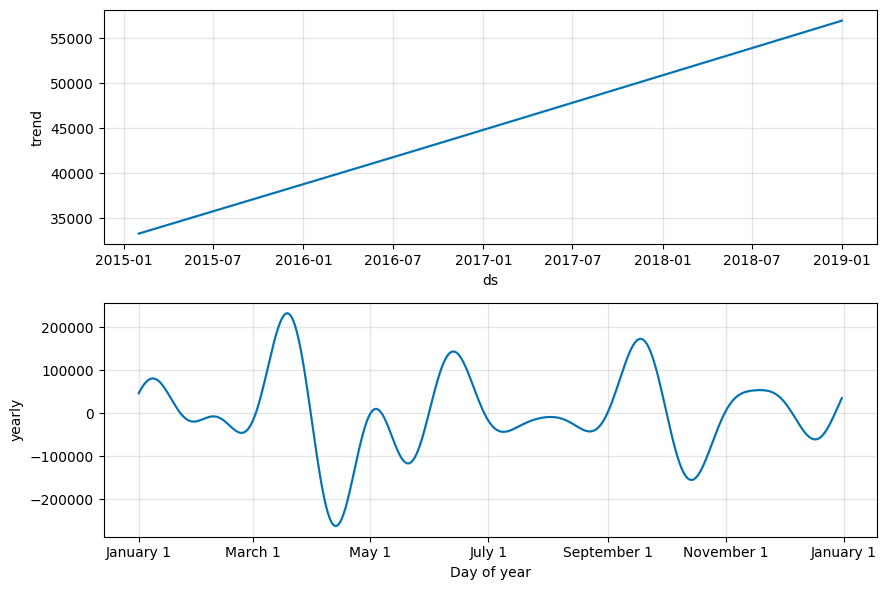

MODEL 3 : XGBOOST


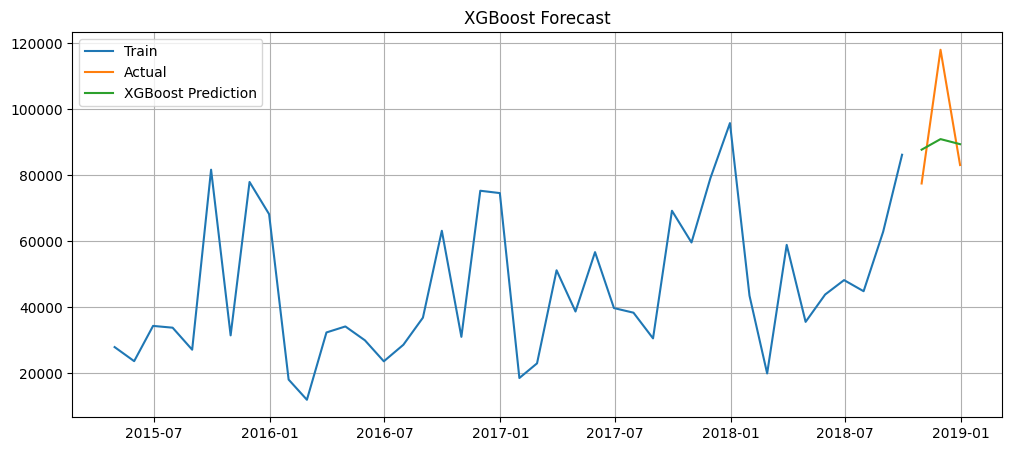

MODEL COMPARISON
     Model           MAE          RMSE       MAPE  Forecast Month 1  \
0   SARIMA  18031.404672  19009.182066  18.966498      66177.602425   
1  Prophet  20250.794428  22318.411366  21.864628      51318.943812   
2  XGBoost  14537.391354  17093.026976  14.590562      87686.601562   

   Forecast Month 2  Forecast Month 3  
0      92049.249682      99965.168723  
1      90325.654736      90041.084430  
2      90888.234375      89354.171875  

Best Model : XGBoost


In [ ]:
# =====================================================
# TASK 3 : SALES FORECASTING USING 3 DIFFERENT MODELS
# =====================================================

# Install Required Libraries
!pip install prophet xgboost -q

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# =====================================================
# Prepare Monthly Sales
# =====================================================

monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

train = monthly_sales[:-3]
test = monthly_sales[-3:]

# =====================================================
# MODEL 1 : SARIMA
# =====================================================

print("="*60)
print("MODEL 1 : SARIMA")
print("="*60)

sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima.fit()

sarima_forecast = sarima_fit.forecast(steps=3)

plt.figure(figsize=(12,5))
plt.plot(train.index, train,label="Train")
plt.plot(test.index,test,label="Actual")
plt.plot(test.index,sarima_forecast,label="SARIMA Forecast")
plt.title("SARIMA Forecast")
plt.legend()
plt.grid(True)
plt.show()

sarima_mae = mean_absolute_error(test,sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test,sarima_forecast))
sarima_mape = np.mean(np.abs((test-sarima_forecast)/test))*100

# =====================================================
# MODEL 2 : FACEBOOK PROPHET
# =====================================================

print("="*60)
print("MODEL 2 : PROPHET")
print("="*60)

prophet_df = monthly_sales.reset_index()
prophet_df.columns=["ds","y"]

train_prophet = prophet_df[:-3]

model = Prophet()

model.fit(train_prophet)

future = model.make_future_dataframe(periods=3,freq='ME')

forecast = model.predict(future)

prophet_forecast = forecast["yhat"].tail(3).values

model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

model.plot_components(forecast)
plt.show()

prophet_mae = mean_absolute_error(test,prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test,prophet_forecast))
prophet_mape = np.mean(np.abs((test-prophet_forecast)/test))*100

# =====================================================
# MODEL 3 : XGBOOST
# =====================================================

print("="*60)
print("MODEL 3 : XGBOOST")
print("="*60)

xgb_df = monthly_sales.to_frame()

xgb_df["Lag1"]=xgb_df["Sales"].shift(1)
xgb_df["Lag2"]=xgb_df["Sales"].shift(2)
xgb_df["Lag3"]=xgb_df["Sales"].shift(3)

xgb_df["RollingMean"]=xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"]=xgb_df.index.month
xgb_df["Quarter"]=xgb_df.index.quarter

xgb_df=xgb_df.dropna()

X=xgb_df.drop("Sales",axis=1)
y=xgb_df["Sales"]

X_train=X[:-3]
X_test=X[-3:]

y_train=y[:-3]
y_test=y[-3:]

xgb=XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred=xgb.predict(X_test)

plt.figure(figsize=(12,5))
plt.plot(y_train.index,y_train,label="Train")
plt.plot(y_test.index,y_test,label="Actual")
plt.plot(y_test.index,xgb_pred,label="XGBoost Prediction")
plt.title("XGBoost Forecast")
plt.legend()
plt.grid(True)
plt.show()

xgb_mae=mean_absolute_error(y_test,xgb_pred)
xgb_rmse=np.sqrt(mean_squared_error(y_test,xgb_pred))
xgb_mape=np.mean(np.abs((y_test-xgb_pred)/y_test))*100

# =====================================================
# MODEL COMPARISON
# =====================================================

comparison=pd.DataFrame({

"Model":["SARIMA","Prophet","XGBoost"],

"MAE":[sarima_mae,prophet_mae,xgb_mae],

"RMSE":[sarima_rmse,prophet_rmse,xgb_rmse],

"MAPE":[sarima_mape,prophet_mape,xgb_mape],

"Forecast Month 1":[sarima_forecast.iloc[0],
                    prophet_forecast[0],
                    xgb_pred[0]],

"Forecast Month 2":[sarima_forecast.iloc[1],
                    prophet_forecast[1],
                    xgb_pred[1]],

"Forecast Month 3":[sarima_forecast.iloc[2],
                    prophet_forecast[2],
                    xgb_pred[2]]

})

print("="*60)
print("MODEL COMPARISON")
print("="*60)

print(comparison)

best_model=comparison.loc[comparison["RMSE"].idxmin(),"Model"]

print("\nBest Model :",best_model)

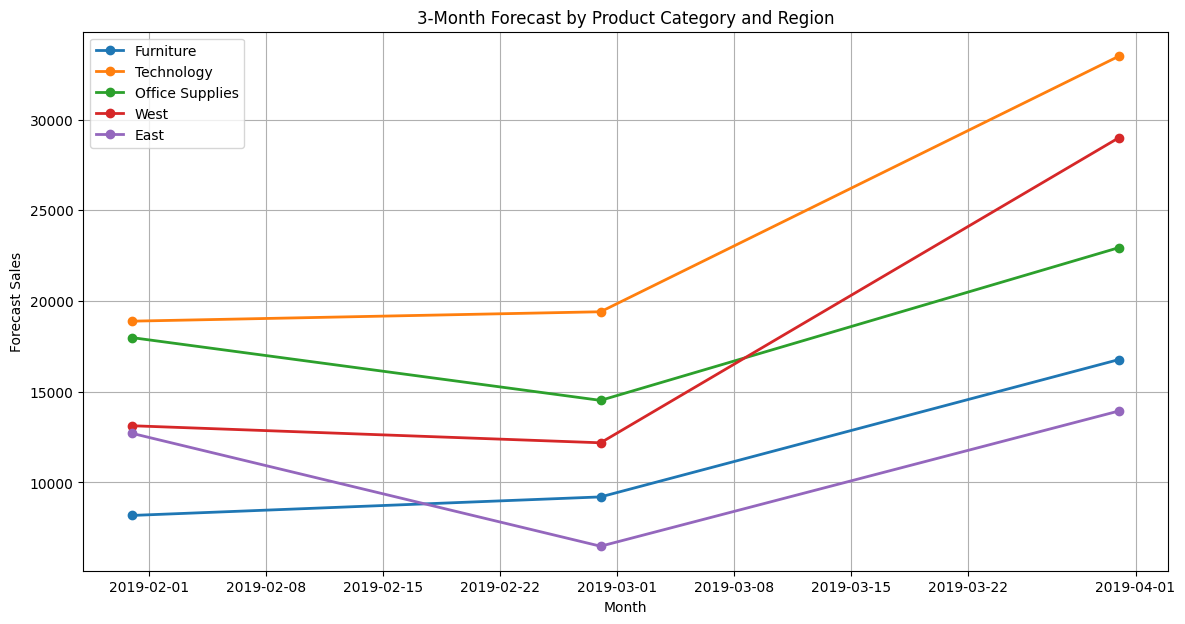


Forecast Table
            Furniture    Technology  Office Supplies          West  \
Month 1   8183.304570  18891.950938     17981.555068  13126.550923   
Month 2   9204.587098  19410.209792     14525.435591  12187.364098   
Month 3  16774.204288  33495.647039     22943.516112  29001.185123   

                 East  
Month 1  12701.878881  
Month 2   6486.114986  
Month 3  13938.823312  

Growth Ranking
West               15874.634200
Technology         14603.696101
Furniture           8590.899718
Office Supplies     4961.961045
East                1236.944431
dtype: float64

Strongest Upcoming Growth:
West


In [ ]:
# =====================================================
# TASK 4 : PRODUCT CATEGORY & REGION LEVEL FORECASTING
# =====================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Segments to Forecast
segments = {
    "Furniture": df[df["Category"]=="Furniture"],
    "Technology": df[df["Category"]=="Technology"],
    "Office Supplies": df[df["Category"]=="Office Supplies"],
    "West": df[df["Region"]=="West"],
    "East": df[df["Region"]=="East"]
}

forecast_results = {}

plt.figure(figsize=(14,7))

for name, data in segments.items():

    # Monthly Sales
    monthly = data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum()

    # Skip if too little data
    if len(monthly) < 24:
        print(f"Not enough data for {name}")
        continue

    # Train SARIMA
    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    result = model.fit(disp=False)

    # Forecast next 3 months
    forecast = result.forecast(steps=3)

    forecast_results[name] = forecast

    # Plot Forecast
    plt.plot(
        forecast.index,
        forecast.values,
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("3-Month Forecast by Product Category and Region")
plt.xlabel("Month")
plt.ylabel("Forecast Sales")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Forecast Table
# =====================================================

forecast_table = pd.DataFrame()

for name, values in forecast_results.items():
    forecast_table[name] = values.values

forecast_table.index = ["Month 1", "Month 2", "Month 3"]

print("\nForecast Table")
print(forecast_table)

# =====================================================
# Strongest Growth
# =====================================================

growth = {}

for name, values in forecast_results.items():
    growth[name] = values.iloc[-1] - values.iloc[0]

growth = pd.Series(growth).sort_values(ascending=False)

print("\nGrowth Ranking")
print(growth)

print("\nStrongest Upcoming Growth:")
print(growth.idxmax())

Weekly Sales
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914


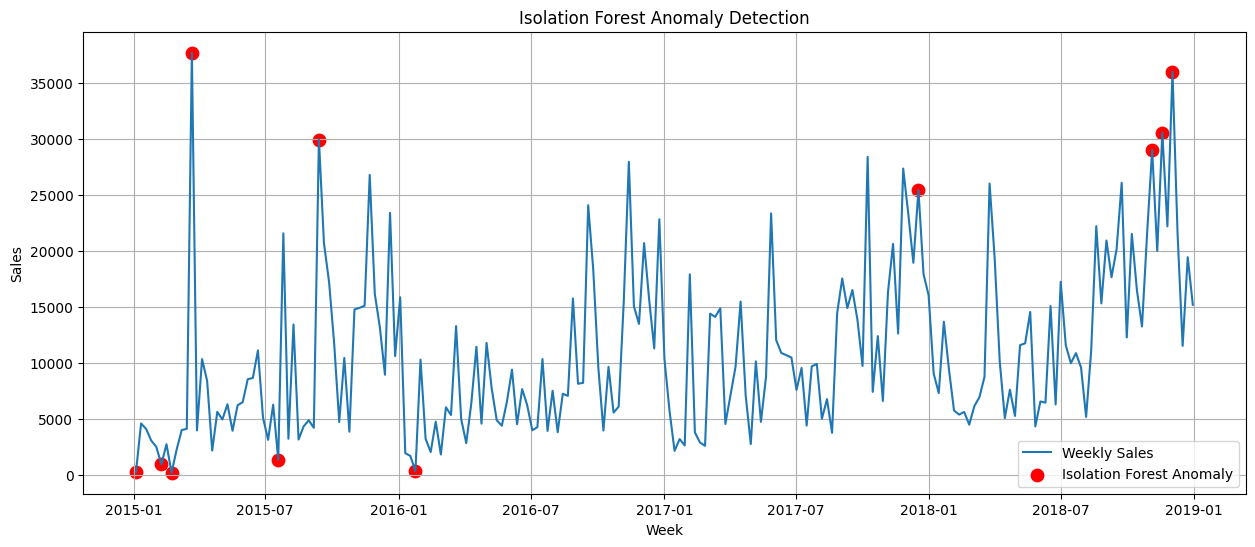

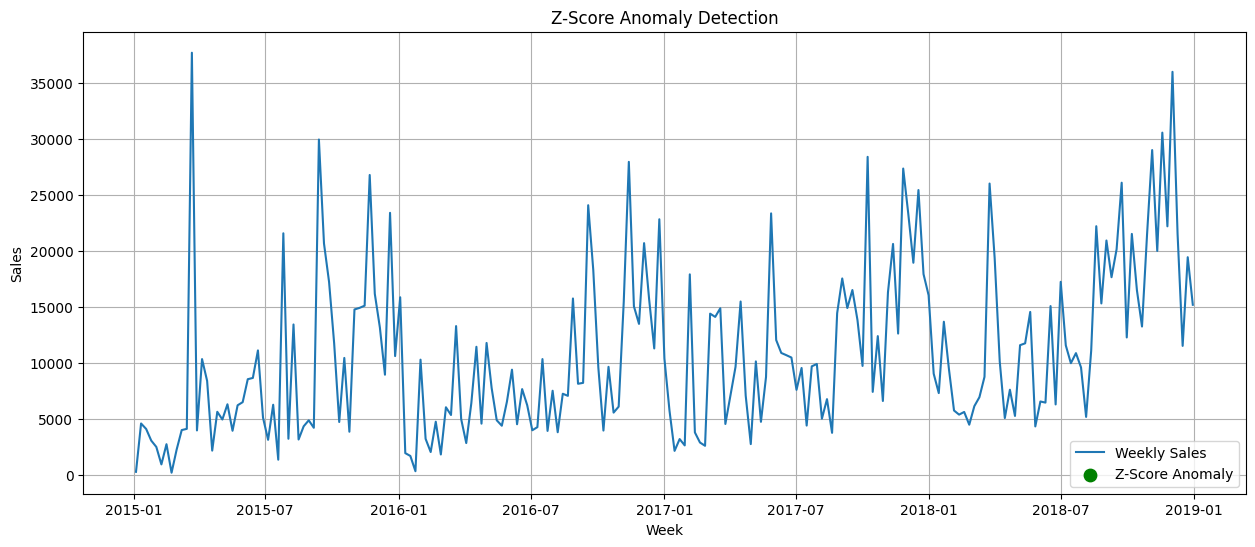


Comparison of Isolation Forest and Z-Score
    Order Date       Sales IF_Anomaly Z_Anomaly
0   2015-01-04    304.5080    Anomaly    Normal
1   2015-01-11   4619.1080     Normal    Normal
2   2015-01-18   4130.5330     Normal    Normal
3   2015-01-25   3092.5440     Normal    Normal
4   2015-02-01   2527.9140     Normal    Normal
..         ...         ...        ...       ...
204 2018-12-02  35998.9000    Anomaly    Normal
205 2018-12-09  21537.2410     Normal    Normal
206 2018-12-16  11542.8340     Normal    Normal
207 2018-12-23  19457.0680     Normal    Normal
208 2018-12-30  15210.8858     Normal    Normal

[209 rows x 4 columns]

Possible Explanations for Detected Anomalies:
2015-01-04 : Sales = 304.51
Possible reason: Promotional campaign, festive season, clearance sale, supply issue, or unexpected demand.

2015-02-08 : Sales = 968.53
Possible reason: Promotional campaign, festive season, clearance sale, supply issue, or unexpected demand.

2015-02-22 : Sales = 224.91
Possible 

In [ ]:
# =====================================================
# TASK 5 : ANOMALY DETECTION IN SALES DATA
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

# -----------------------------------------------------
# Weekly Sales
# -----------------------------------------------------

weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()

print("Weekly Sales")
print(weekly_sales.head())

# =====================================================
# METHOD 1 : ISOLATION FOREST
# =====================================================

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["IF_Anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])

weekly_sales["IF_Anomaly"] = weekly_sales["IF_Anomaly"].map({
    1:"Normal",
    -1:"Anomaly"
})

# =====================================================
# Plot Isolation Forest
# =====================================================

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_sales[
    weekly_sales["IF_Anomaly"]=="Anomaly"
]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Isolation Forest Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# METHOD 2 : Z-SCORE
# =====================================================

weekly_sales["Rolling Mean"] = weekly_sales["Sales"].rolling(4).mean()

weekly_sales["Rolling Std"] = weekly_sales["Sales"].rolling(4).std()

weekly_sales["Z-Score"] = (
    weekly_sales["Sales"] -
    weekly_sales["Rolling Mean"]
) / weekly_sales["Rolling Std"]

weekly_sales["Z_Anomaly"] = np.where(
    abs(weekly_sales["Z-Score"]) > 2,
    "Anomaly",
    "Normal"
)

# =====================================================
# Plot Z-Score
# =====================================================

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z_anomaly = weekly_sales[
    weekly_sales["Z_Anomaly"]=="Anomaly"
]

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Anomaly Detection")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# COMPARISON
# =====================================================

comparison = weekly_sales[[
    "Order Date",
    "Sales",
    "IF_Anomaly",
    "Z_Anomaly"
]]

print("\nComparison of Isolation Forest and Z-Score")
print(comparison)

# =====================================================
# Possible Real-World Explanation
# =====================================================

print("\nPossible Explanations for Detected Anomalies:")

for _, row in anomaly.iterrows():
    print(f"{row['Order Date'].date()} : Sales = {row['Sales']:.2f}")
    print("Possible reason: Promotional campaign, festive season, clearance sale, supply issue, or unexpected demand.\n")

Feature Table
              Total Sales  Growth Rate   Volatility  Average Order Value
Sub-Category                                                            
Accessories   164186.7000   502.615806  2579.994809           217.178175
Appliances    104618.4030  1977.573101  1821.621539           227.926804
Art            26705.4100   387.190237   330.488343            34.019631
Binders       200028.7850   484.392296  3848.223648           134.067550
Bookcases     113813.1987   261.772161  2220.405080           503.598224


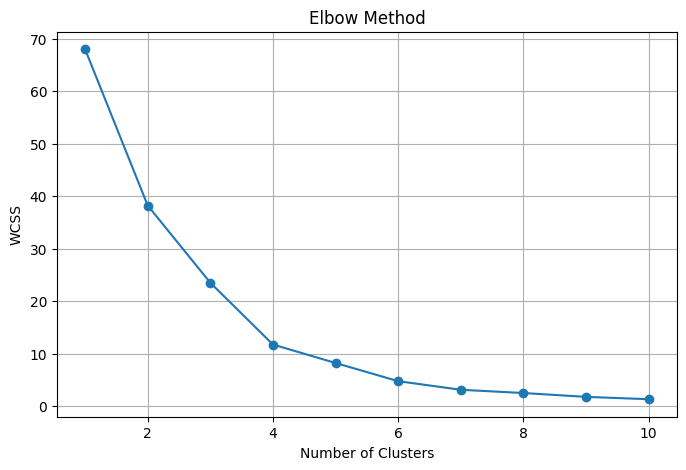

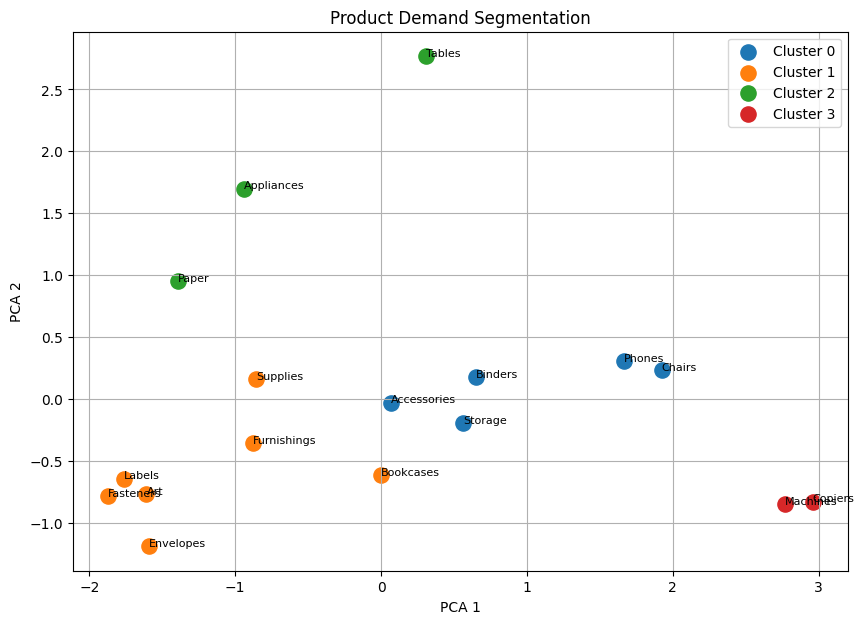


Demand Segmentation
              Total Sales  Growth Rate   Volatility  Average Order Value  \
Sub-Category                                                               
Accessories   164186.7000   502.615806  2579.994809           217.178175   
Appliances    104618.4030  1977.573101  1821.621539           227.926804   
Art            26705.4100   387.190237   330.488343            34.019631   
Binders       200028.7850   484.392296  3848.223648           134.067550   
Bookcases     113813.1987   261.772161  2220.405080           503.598224   
Chairs        322822.7310   257.390883  4407.232960           531.833165   
Copiers       146248.0940   122.668129  5500.774391          2215.880212   
Envelopes      16128.0460   113.449269   228.218688            65.032444   
Fasteners       3001.9600   446.375321    48.742229            14.027850   
Furnishings    89212.0180   491.629693  1360.017867            95.823865   
Labels         12347.7260   522.884727   223.471218            34.5

In [ ]:
# =====================================================
# TASK 6 : PRODUCT DEMAND SEGMENTATION USING CLUSTERING
# =====================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------------------------
# Aggregate Product Features
# -----------------------------------------------------

# Monthly Sales by Sub-Category
monthly = df.groupby(
    ["Sub-Category", pd.Grouper(key="Order Date", freq="ME")]
)["Sales"].sum().reset_index()

# Total Sales
total_sales = monthly.groupby("Sub-Category")["Sales"].sum()

# Sales Growth Rate
growth = monthly.groupby("Sub-Category")["Sales"].apply(
    lambda x: ((x.iloc[-1]-x.iloc[0])/x.iloc[0]*100)
    if len(x)>1 and x.iloc[0]!=0 else 0
)

# Sales Volatility
volatility = monthly.groupby("Sub-Category")["Sales"].std()

# Average Order Value
avg_order = df.groupby("Sub-Category")["Sales"].mean()

# Feature Table
features = pd.DataFrame({
    "Total Sales": total_sales,
    "Growth Rate": growth,
    "Volatility": volatility,
    "Average Order Value": avg_order
})

features = features.fillna(0)

print("Feature Table")
print(features.head())

# -----------------------------------------------------
# Standardize Features
# -----------------------------------------------------

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

# -----------------------------------------------------
# Elbow Method
# -----------------------------------------------------

wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

# -----------------------------------------------------
# KMeans
# -----------------------------------------------------

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(scaled)

# -----------------------------------------------------
# PCA
# -----------------------------------------------------

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled)

features["PCA1"] = pca_result[:,0]
features["PCA2"] = pca_result[:,1]

# -----------------------------------------------------
# Cluster Plot
# -----------------------------------------------------

plt.figure(figsize=(10,7))

for c in sorted(features["Cluster"].unique()):

    subset = features[features["Cluster"]==c]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        s=120,
        label=f"Cluster {c}"
    )

    for i in subset.index:
        plt.text(
            subset.loc[i,"PCA1"],
            subset.loc[i,"PCA2"],
            i,
            fontsize=8
        )

plt.title("Product Demand Segmentation")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.legend()

plt.grid(True)

plt.show()

# -----------------------------------------------------
# Cluster Labels
# -----------------------------------------------------

labels = {
    0:"High Volume, Stable Demand",
    1:"Low Volume, High Volatility",
    2:"Growing Demand",
    3:"Declining Demand"
}

features["Demand Segment"] = features["Cluster"].map(labels)

print("\nDemand Segmentation")
print(features[[
    "Total Sales",
    "Growth Rate",
    "Volatility",
    "Average Order Value",
    "Demand Segment"
]])

# -----------------------------------------------------
# Stocking Strategy
# -----------------------------------------------------

print("\n================ STOCKING STRATEGIES ================\n")

print("High Volume, Stable Demand")
print("- Maintain high inventory levels.")
print("- Ensure continuous stock availability.")
print()

print("Low Volume, High Volatility")
print("- Keep limited inventory.")
print("- Monitor demand frequently.")
print()

print("Growing Demand")
print("- Increase inventory gradually.")
print("- Focus marketing on these products.")
print()

print("Declining Demand")
print("- Reduce stock levels.")
print("- Consider discounts or clearance sales.")